<a href="https://colab.research.google.com/github/BNagaraj2004/codealpha_projects-/blob/main/codealpha_bigproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

BASE_URL = "https://books.toscrape.com/catalogue/page-{}.html"

all_books = []

for page in range(1, 51):
    try:
        print(f"Scraping page {page}")
        response = requests.get(BASE_URL.format(page), timeout=10)
        response.raise_for_status()
    except requests.exceptions.RequestException as e:
        print(f"Failed on page {page}: {e}")
        continue

    soup = BeautifulSoup(response.content, "html.parser")
    books = soup.find_all("article", class_="product_pod")

    for book in books:
        try:
            title = book.h3.a.get("title", "").strip()
            price = book.find("p", class_="price_color")
            price = price.text.strip() if price else "0"

            rating_tag = book.find("p", class_="star-rating")
            rating = rating_tag["class"][1] if rating_tag else "Zero"

            availability_tag = book.find("p", class_="instock availability")
            availability = availability_tag.text.strip() if availability_tag else "Unknown"

            all_books.append([title, price, rating, availability])

        except Exception as e:
            print("Error parsing book:", e)
            continue

    time.sleep(1)

df = pd.DataFrame(
    all_books,
    columns=["Title", "Price", "Rating", "Availability"]
)

df.to_csv("books_raw_data.csv", index=False, encoding="utf-8")

print("✅ Web scraping completed successfully.")


Scraping page 1
Scraping page 2
Scraping page 3
Scraping page 4
Scraping page 5
Scraping page 6
Scraping page 7
Scraping page 8
Scraping page 9
Scraping page 10
Scraping page 11
Scraping page 12
Scraping page 13
Scraping page 14
Scraping page 15
Scraping page 16
Scraping page 17
Scraping page 18
Scraping page 19
Scraping page 20
Scraping page 21
Scraping page 22
Scraping page 23
Scraping page 24
Scraping page 25
Scraping page 26
Scraping page 27
Scraping page 28
Scraping page 29
Scraping page 30
Scraping page 31
Scraping page 32
Scraping page 33
Scraping page 34
Scraping page 35
Scraping page 36
Scraping page 37
Scraping page 38
Scraping page 39
Scraping page 40
Scraping page 41
Scraping page 42
Scraping page 43
Scraping page 44
Scraping page 45
Scraping page 46
Scraping page 47
Scraping page 48
Scraping page 49
Scraping page 50
✅ Web scraping completed successfully.


In [3]:
import pandas as pd

df = pd.read_csv("books_raw_data.csv", encoding="utf-8")

# ---- CLEAN PRICE ----
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace("[^0-9.]", "", regex=True)
)

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Price"].fillna(0, inplace=True)

# ---- CLEAN RATING ----
rating_map = {
    "Zero": 0,
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map).fillna(0).astype(int)

# ---- STOCK FLAG ----
df["In_Stock"] = df["Availability"].apply(
    lambda x: 1 if "In stock" in str(x) else 0
)

# ---- BASIC VALIDATION ----
assert df["Price"].dtype in ["float64", "int64"]
assert df["Rating"].dtype == "int64"

print("Total Books:", len(df))
print("Average Price:", round(df["Price"].mean(), 2))
print("Rating Distribution:\n", df["Rating"].value_counts())

df.to_csv("books_cleaned_data.csv", index=False, encoding="utf-8")

print("✅ EDA completed successfully.")


Total Books: 1000
Average Price: 35.07
Rating Distribution:
 Rating
1    226
3    203
5    196
2    196
4    179
Name: count, dtype: int64
✅ EDA completed successfully.


/tmp/ipython-input-2089313137.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Price"].fillna(0, inplace=True)


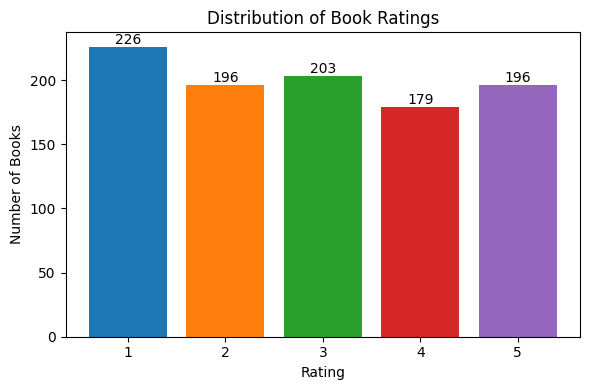

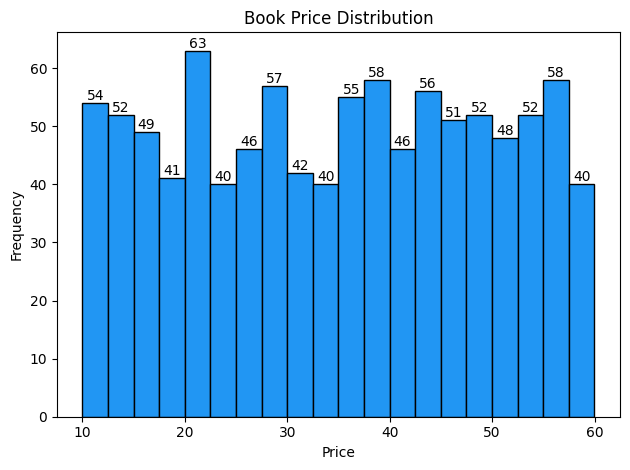

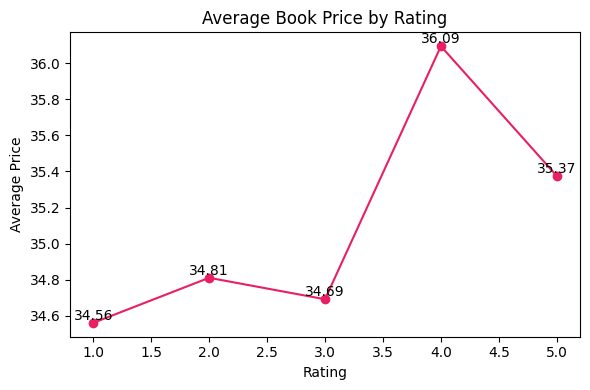

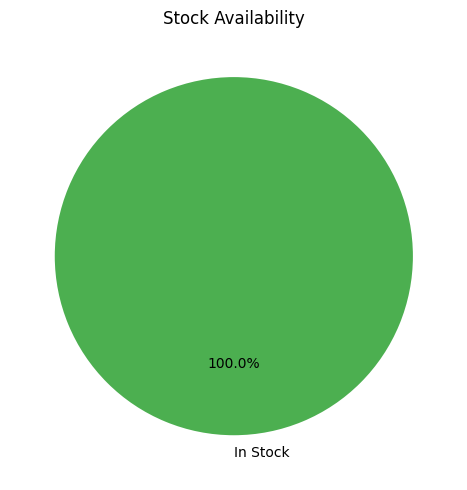

/tmp/ipython-input-2662656617.py:127: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(price_data, patch_artist=True, labels=ratings_sorted)


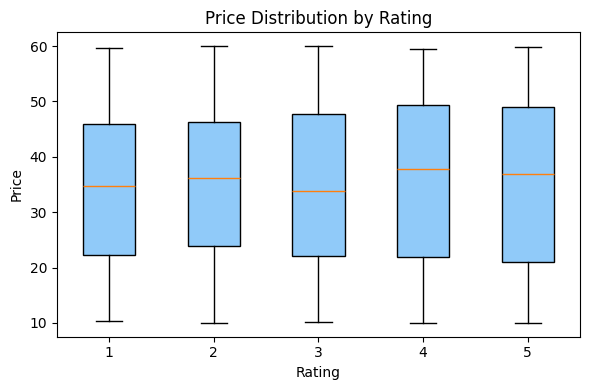

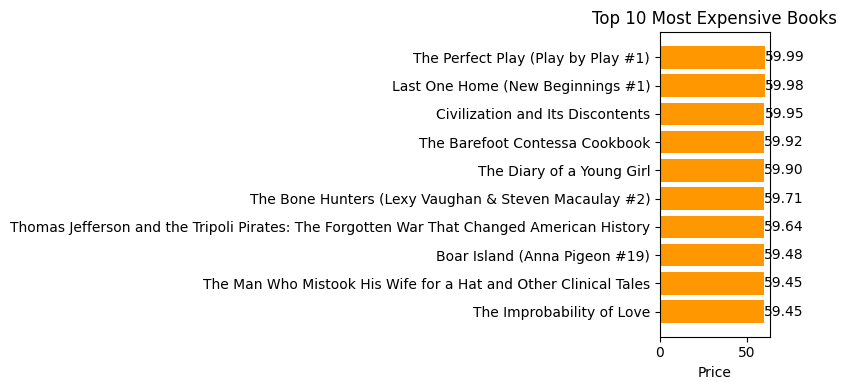

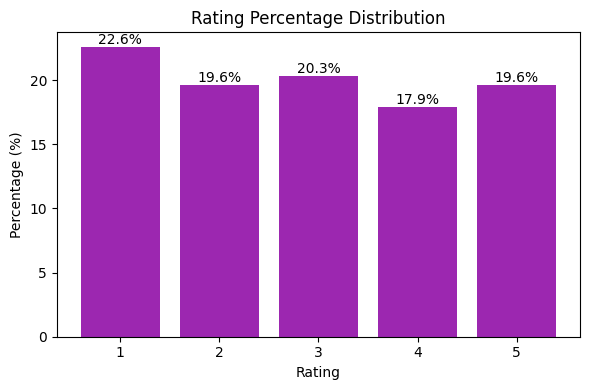

✅ All 7 visualizations generated successfully without errors.


In [4]:
# =========================================
# ALL-IN-ONE ERROR-FREE DATA VISUALIZATION
# =========================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------- PATH SETUP ----------
BASE_DIR = os.getcwd()
file_path = os.path.join(BASE_DIR, "books_cleaned_data.csv")

if not os.path.exists(file_path):
    raise FileNotFoundError(f"File not found: {file_path}")

df = pd.read_csv(file_path, encoding="utf-8")

# ---------- BASIC VALIDATION ----------
for col in ["Price", "Rating", "In_Stock"]:
    if col not in df.columns:
        raise ValueError(f"Missing column: {col}")

# ==================================================
# VISUAL 1: Rating Distribution (Bar Chart)
# ==================================================
rating_counts = df["Rating"].value_counts().sort_index()

plt.figure(figsize=(6,4))
bars = plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values,
    color=plt.cm.tab10.colors[:len(rating_counts)]
)

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha="center", va="bottom"
    )

plt.tight_layout()
plt.show()

# ==================================================
# VISUAL 2: Price Distribution (Histogram)
# ==================================================
counts, bins, patches = plt.hist(
    df["Price"],
    bins=20,
    color="#2196F3",
    edgecolor="black"
)

plt.title("Book Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width()/2,
            count,
            int(count),
            ha="center", va="bottom"
        )

plt.tight_layout()
plt.show()

# ==================================================
# VISUAL 3: Average Price by Rating (Line Chart)
# ==================================================
avg_price = df.groupby("Rating")["Price"].mean()

plt.figure(figsize=(6,4))
plt.plot(
    avg_price.index,
    avg_price.values,
    marker="o",
    color="#E91E63"
)

plt.title("Average Book Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price")

for x, y in zip(avg_price.index, avg_price.values):
    plt.text(x, y, f"{y:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

# ==================================================
# VISUAL 4: Stock Availability (Pie Chart)
# ==================================================
stock_counts = df["In_Stock"].value_counts()

labels = ["In Stock" if i == 1 else "Out of Stock" for i in stock_counts.index]

plt.figure(figsize=(5,5))
plt.pie(
    stock_counts.values,
    labels=labels,
    autopct="%1.1f%%",
    colors=["#4CAF50", "#F44336"],
    startangle=90
)

plt.title("Stock Availability")
plt.tight_layout()
plt.show()

# ==================================================
# VISUAL 5: Price Distribution by Rating (Box Plot)
# ==================================================
ratings_sorted = sorted(df["Rating"].unique())
price_data = [df[df["Rating"] == r]["Price"] for r in ratings_sorted]

plt.figure(figsize=(6,4))
box = plt.boxplot(price_data, patch_artist=True, labels=ratings_sorted)

for patch in box["boxes"]:
    patch.set_facecolor("#90CAF9")

plt.title("Price Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

# ==================================================
# VISUAL 6: Top 10 Most Expensive Books (Horizontal Bar)
# ==================================================
top10 = df.sort_values("Price", ascending=False).head(10)

plt.figure(figsize=(8,4))
bars = plt.barh(
    top10["Title"],
    top10["Price"],
    color="#FF9800"
)

plt.title("Top 10 Most Expensive Books")
plt.xlabel("Price")
plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

# ==================================================
# VISUAL 7: Rating Percentage Distribution
# ==================================================
rating_percent = (rating_counts / rating_counts.sum()) * 100

plt.figure(figsize=(6,4))
bars = plt.bar(
    rating_percent.index.astype(str),
    rating_percent.values,
    color="#9C27B0"
)

plt.title("Rating Percentage Distribution")
plt.xlabel("Rating")
plt.ylabel("Percentage (%)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center", va="bottom"
    )

plt.tight_layout()
plt.show()

print("✅ All 7 visualizations generated successfully without errors.")
